In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### VotingClassifier

In [2]:
# Create a dataset using make_moons
from sklearn.datasets import make_moons

In [3]:
# Get data for dataset
x, y = make_moons(n_samples=1000, noise=0.2)
# Here x is inpendent and y is dependent data

In [4]:
# Create a dataframe using x and y for tablular visualization
df = {"x1": x[:, 0], "x2": x[:, 1], "y": y}
dataset = pd.DataFrame(df)
dataset.head(3)

,x1,x2,y
0,-0.341863,0.877581,0
1,0.909708,-0.342428,1
2,0.015363,0.818609,1


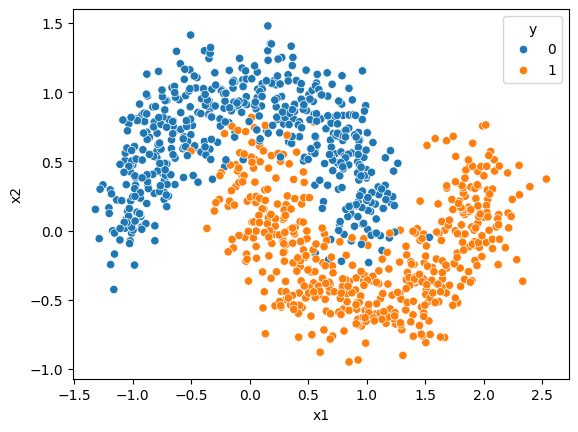

In [5]:
# Visualize data
sns.scatterplot(x="x1", y="x2", data=dataset, hue="y")
plt.show()

In [6]:
# Train test split
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
# Train  different models 
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [9]:
# DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)
dtc.score(x_train, y_train), dtc.score(x_test, y_test)

(1.0, 0.95)

In [10]:
# SVC
svc = SVC()
svc.fit(x_train, y_train)
svc.score(x_train, y_train), svc.score(x_test, y_test)

(0.95875, 0.975)

In [11]:
# GaussinaNB
gnb = DecisionTreeClassifier()
gnb.fit(x_train, y_train)
gnb.score(x_train, y_train), gnb.score(x_test, y_test)

(1.0, 0.945)

In [12]:
# Use Ensemble Learning (VotingClassifier)
from sklearn.ensemble import VotingClassifier

In [13]:
# Create a list of tuples with classifier names and instances (estimators)
l = [("dtc", DecisionTreeClassifier()), ("svc", SVC()), ("gnb", GaussianNB())]

In [14]:
# Create the VotingClassifier model
vc = VotingClassifier(l) 
# You can also use weightage in terms of list: weights=[1, 2, 3]
vc.fit(x_train, y_train)

VotingClassifier(estimators=[('dtc', DecisionTreeClassifier()), ('svc', SVC()),
                             ('gnb', GaussianNB())])

In [15]:
vc.score(x_train, y_train), vc.score(x_test, y_test)

(0.96875, 0.98)

In [16]:
# Lets create a datframe for clear visualization
predicted = {
    "DecisionTreeClassifier": dtc.predict(x_test),
    "SVC": svc.predict(x_test),
    "GaussianNB": gnb.predict(x_test),
    "VotingClassifier": vc.predict(x_test),
}
# Create a dataframe
pd.DataFrame(predicted)
# The most repeated result (mode) is final result by VotingClassifier

,DecisionTreeClassifier,SVC,GaussianNB,VotingClassifier
0,0,0,0,0
1,1,1,1,1
2,0,0,0,0
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
195,1,1,1,1
196,1,1,1,1
197,0,0,0,0
198,0,0,0,0


#### VotingRegressor

In [19]:
dataset = pd.read_csv("../assets/csv-files/maths.csv")
dataset.head(3)

,Number1,Number2,Number3,Total Sum
0,971.844377,1760.131196,1689.181218,4421.15679
1,NaN,NaN,NaN,0.00000
2,NaN,NaN,NaN,0.00000


In [20]:
# Check for null values
dataset.isnull().sum()

Number1      454
Number2      915
Number3      931
Total Sum    499
dtype: int64

In [21]:
# Remove all the null values instead of filling (big dataset)
dataset.dropna(inplace=True)

In [22]:
# Select dependent and indpendent data
x = dataset[["Number1"]]
y = dataset["Total Sum"]

In [23]:
# Train test split
from sklearn.model_selection import train_test_split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
# Train different models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [26]:
# LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_train, y_train), lr.score(x_test, y_test)

(0.8184561342301966, 0.8184654628573008)

In [27]:
# DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(x_train, y_train)
dtr.score(x_train, y_train), dtr.score(x_test, y_test)

(1.0, 0.641692798616695)

In [28]:
# SVR
svr = SVR()
svr.fit(x_train, y_train)
svr.score(x_train, y_train), svr.score(x_test, y_test)

(0.5764312523340507, 0.5866394863115916)

In [29]:
# Use Ensemble Learning (VotingRegressor)
from sklearn.ensemble import VotingRegressor

In [30]:
# Create a list of tuples with classifier names and instances (estimators)
l = [("lr", LinearRegression()), ("dtr", DecisionTreeRegressor()), ("svr", SVR())]

In [31]:
vr = VotingRegressor(l, weights=[2, 3, 4])
vr.fit(x_train, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('dtr', DecisionTreeRegressor()), ('svr', SVR())],
                weights=[2, 3, 4])

In [32]:
vr.score(x_train, y_train), vr.score(x_test, y_test)

(0.871179005030356, 0.7545515801172116)

In [33]:
# Now lets see how VotingRegressor works by comparision on dataset
df = {
    "LinearRegression": lr.predict(x_test),
    "DecisionTreeRegressor": dtr.predict(x_test),
    "SVR": svr.predict(x_test),
    "VotingRegressor": vr.predict(x_test),
}
# Create a dataframe
pd.DataFrame(df).head(3)
# VotingRegressor gives average of other models

,LinearRegression,DecisionTreeRegressor,SVR,VotingRegressor
0,3624.367102,3924.410696,3029.426005,3459.963368
1,2696.132938,2989.111036,2635.392038,2766.796349
2,2648.716045,2453.359032,2600.843747,2562.320464
